In [20]:
import numpy as np
import matplotlib.pyplot as plt


In [21]:
def estimate_gaussian_parameters(X):
    mu = np.mean(X, axis=0)
    covariance_matrix = np.cov(X, rowvar=False)
    return mu, covariance_matrix


In [22]:
def gaussian_pdf(X, mu, covariance_matrix):
    n_features = X.shape[1]
    covariance_matrix = covariance_matrix + 1e-8 * np.eye(n_features)

    centered = X - mu
    inverse_covariance = np.linalg.inv(covariance_matrix)
    determinant = np.linalg.det(covariance_matrix)

    coefficient = 1 / np.sqrt(((2 * np.pi) ** n_features) * determinant)
    exponent = np.einsum("ij,jk,ik->i", centered, inverse_covariance, centered)
    probabilities = coefficient * np.exp(-0.5 * exponent)
    return probabilities


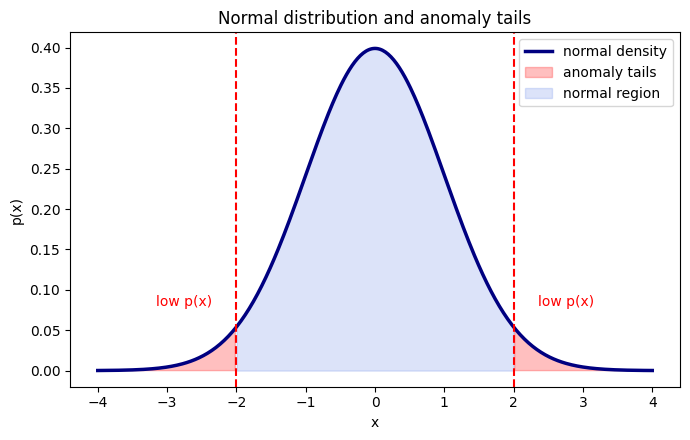

In [23]:
# Visualize a 1D normal distribution and anomaly tails
x = np.linspace(-4, 4, 400)
mu_1d = 0
sigma_1d = 1
normal_density = (1 / np.sqrt(2 * np.pi * sigma_1d**2)) * np.exp(-((x - mu_1d) ** 2) / (2 * sigma_1d**2))

left_threshold = -2
right_threshold = 2

plt.figure(figsize=(7, 4.5))
plt.plot(x, normal_density, color="navy", linewidth=2.5, label="normal density")
plt.fill_between(
    x,
    normal_density,
    where=(x < left_threshold) | (x > right_threshold),
    color="red",
    alpha=0.25,
    label="anomaly tails",
)
plt.fill_between(
    x,
    normal_density,
    where=(x >= left_threshold) & (x <= right_threshold),
    color="royalblue",
    alpha=0.18,
    label="normal region",
)
plt.axvline(left_threshold, color="red", linestyle="--", linewidth=1.5)
plt.axvline(right_threshold, color="red", linestyle="--", linewidth=1.5)
plt.text(left_threshold - 0.35, 0.08, "low p(x)", color="red", ha="right")
plt.text(right_threshold + 0.35, 0.08, "low p(x)", color="red", ha="left")
plt.title("Normal distribution and anomaly tails")
plt.xlabel("x")
plt.ylabel("p(x)")
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
def predict_anomalies(probabilities, epsilon):
    return probabilities < epsilon


In [25]:
# Use the same correlated 2D dataset as the PCA notebook
rng = np.random.default_rng(42)

n_points = 40
pc1 = rng.normal(0, 2.0, size=n_points)
pc2 = rng.normal(0, 0.45, size=n_points)

theta = np.deg2rad(35)
R = np.array([
    [np.cos(theta), -np.sin(theta)],
    [np.sin(theta),  np.cos(theta)],
])

X = np.column_stack([pc1, pc2]) @ R.T
X[:5]


array([[ 0.30737835,  0.62353425],
       [-1.84400343, -0.99280409],
       [ 1.40124157,  0.61556311],
       [ 1.481008  ,  1.16455046],
       [-3.22650663, -2.19512308]])

In [26]:
# Add the same obvious anomalies used in the PCA notebook
anomalies = np.array([
    [1.2, -3.0],
    [2.0, -2.5],
    [-1.4, 2.7],
])

X_with_anomalies = np.vstack([X, anomalies])
true_labels = np.array([0] * len(X) + [1] * len(anomalies))

X_with_anomalies.shape


(43, 2)

In [27]:
# Fit Gaussian on normal data, then score all points
mu, covariance_matrix = estimate_gaussian_parameters(X)

normal_probabilities = gaussian_pdf(X, mu, covariance_matrix)
all_probabilities = gaussian_pdf(X_with_anomalies, mu, covariance_matrix)

epsilon = normal_probabilities.min() * 0.8
predicted_anomaly = predict_anomalies(all_probabilities, epsilon)

print("mu:", mu)
print("covariance matrix:", covariance_matrix)
print("epsilon:", epsilon)
print("predicted anomalies:", np.where(predicted_anomaly)[0])
print("true anomalies:", np.where(true_labels == 1)[0])


mu: [0.05928851 0.04875322]
covariance matrix: [[1.97589797 1.19116322]
 [1.19116322 0.8600174 ]]
epsilon: 0.0043135605313864385
predicted anomalies: [40 41 42]
true anomalies: [40 41 42]


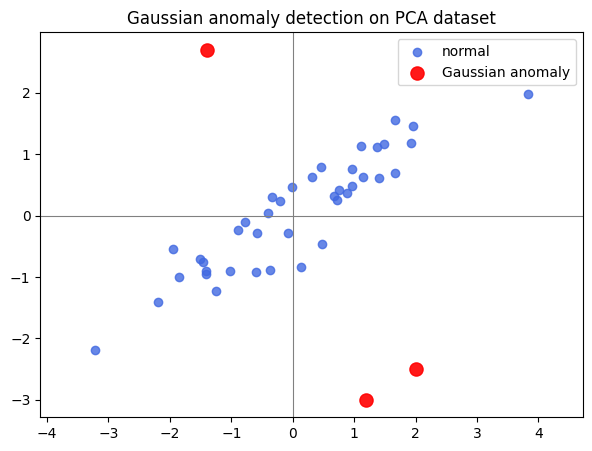

In [28]:
# Plot Gaussian anomaly detection on the same PCA dataset
normal_mask = ~predicted_anomaly
anomaly_mask = predicted_anomaly

plt.figure(figsize=(7, 5))
plt.scatter(
    X_with_anomalies[normal_mask, 0],
    X_with_anomalies[normal_mask, 1],
    color="royalblue",
    alpha=0.8,
    label="normal",
)
plt.scatter(
    X_with_anomalies[anomaly_mask, 0],
    X_with_anomalies[anomaly_mask, 1],
    color="red",
    s=90,
    alpha=0.9,
    label="Gaussian anomaly",
)

plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.axis("equal")
plt.title("Gaussian anomaly detection on PCA dataset")
plt.legend()
plt.show()
